In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install torch torchvision torchaudio --quiet
!pip install roboflow tqdm scikit-learn matplotlib seaborn --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.6/94.6 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 95.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 145.0 MB/s eta 0:00:00


In [3]:
import os

DRIVE_ROOT = "/content/drive/MyDrive"
PROJECT_PATH = f"{DRIVE_ROOT}/Colab Notebooks/computer vision/Ultralytics YOLO/object classification"

os.makedirs(PROJECT_PATH, exist_ok=True)

print("Project will be saved to:", PROJECT_PATH)

Project will be saved to: /content/drive/MyDrive/Colab Notebooks/computer vision/Ultralytics YOLO/object classification


In [4]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="VCLkIHPyGp4Yk2L3u2Ef")
project = rf.workspace("tenifayo").project("emotion-recognition-vweyv")
version = project.version(1)
dataset = version.download("folder")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Emotion-Recognition-1 in folder:: 100%|██████████| 23730/23730 [00:04<00:00, 5730.09it/s]


In [7]:
!cp -r "{dataset.location}" "{PROJECT_PATH}"
DATASET_PATH = f"{PROJECT_PATH}/{dataset.location.split('/')[-1]}"
print(DATASET_PATH)

/content/drive/MyDrive/Colab Notebooks/computer vision/Ultralytics YOLO/object classification/Emotion-Recognition-1


In [8]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

train_dataset = datasets.ImageFolder(f"{DATASET_PATH}/train", transform=transform)
val_dataset = datasets.ImageFolder(f"{DATASET_PATH}/valid", transform=transform)
test_dataset = datasets.ImageFolder(f"{DATASET_PATH}/test", transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

num_classes = len(train_dataset.classes)
print("Classes:", train_dataset.classes)

Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [9]:
import torchvision.models as models
import torch.nn as nn

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Replace final layer
model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 212MB/s]


In [10]:
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

In [11]:
import time
from tqdm import tqdm
from sklearn.metrics import accuracy_score

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)

num_epochs = 10

train_losses = []
val_accuracies = []

start_training_time = time.time()

In [12]:
for epoch in range(num_epochs):
    model.train()
    running_loss = 0

    epoch_start = time.time()

    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_time = time.time() - epoch_start

    # Validation
    model.eval()
    preds, targets = [], []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            preds.extend(predicted.cpu().numpy())
            targets.extend(labels.numpy())

    val_acc = accuracy_score(targets, preds)

    train_losses.append(running_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}")
    print(f"Loss: {running_loss:.4f}")
    print(f"Val Accuracy: {val_acc:.4f}")
    print(f"Epoch Time: {epoch_time:.2f} sec")
    print(f"GPU Memory Used: {torch.cuda.max_memory_allocated()/1024**2:.2f} MB")

100%|██████████| 648/648 [04:38<00:00,  2.33it/s]


Epoch 1
Loss: 1113.2141
Val Accuracy: 0.3424
Epoch Time: 278.05 sec
GPU Memory Used: 444.26 MB


100%|██████████| 648/648 [04:38<00:00,  2.33it/s]


Epoch 2
Loss: 1075.5339
Val Accuracy: 0.3551
Epoch Time: 278.02 sec
GPU Memory Used: 444.26 MB


100%|██████████| 648/648 [04:36<00:00,  2.34it/s]


...

Epoch 8
Loss: 1010.1965
Val Accuracy: 0.3737
Epoch Time: 253.97 sec
GPU Memory Used: 444.26 MB


100%|██████████| 648/648 [04:14<00:00,  2.55it/s]


Epoch 9
Loss: 1012.3568
Val Accuracy: 0.3965
Epoch Time: 254.05 sec
GPU Memory Used: 444.26 MB


100%|██████████| 648/648 [04:13<00:00,  2.55it/s]


Epoch 10
Loss: 998.1230
Val Accuracy: 0.3758
Epoch Time: 253.75 sec
GPU Memory Used: 444.26 MB


In [13]:
total_training_time = time.time() - start_training_time
print("Total Training Time:", total_training_time)

Total Training Time: 2935.3267271518707


              precision    recall  f1-score   support

           0       0.25      0.10      0.14       143
           1       0.17      0.07      0.10        14
           2       0.22      0.03      0.05       142
           3       0.46      0.51      0.49       226
           4       0.41      0.27      0.32       166
           5       0.28      0.68      0.40       189
           6       0.55      0.48      0.51       116

    accuracy                           0.37       996
   macro avg       0.33      0.31      0.29       996
weighted avg       0.36      0.37      0.33       996



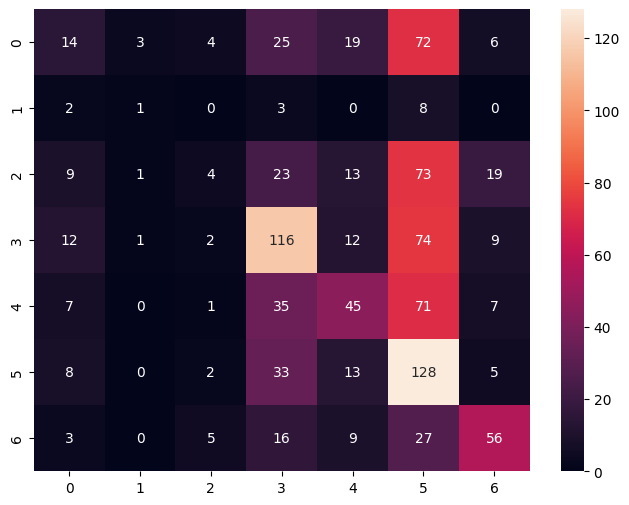

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model.eval()
preds, targets = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        preds.extend(predicted.cpu().numpy())
        targets.extend(labels.numpy())

print(classification_report(targets, preds))

cm = confusion_matrix(targets, preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.savefig(f"{PROJECT_PATH}/confusion_matrix_resnet.png")

Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


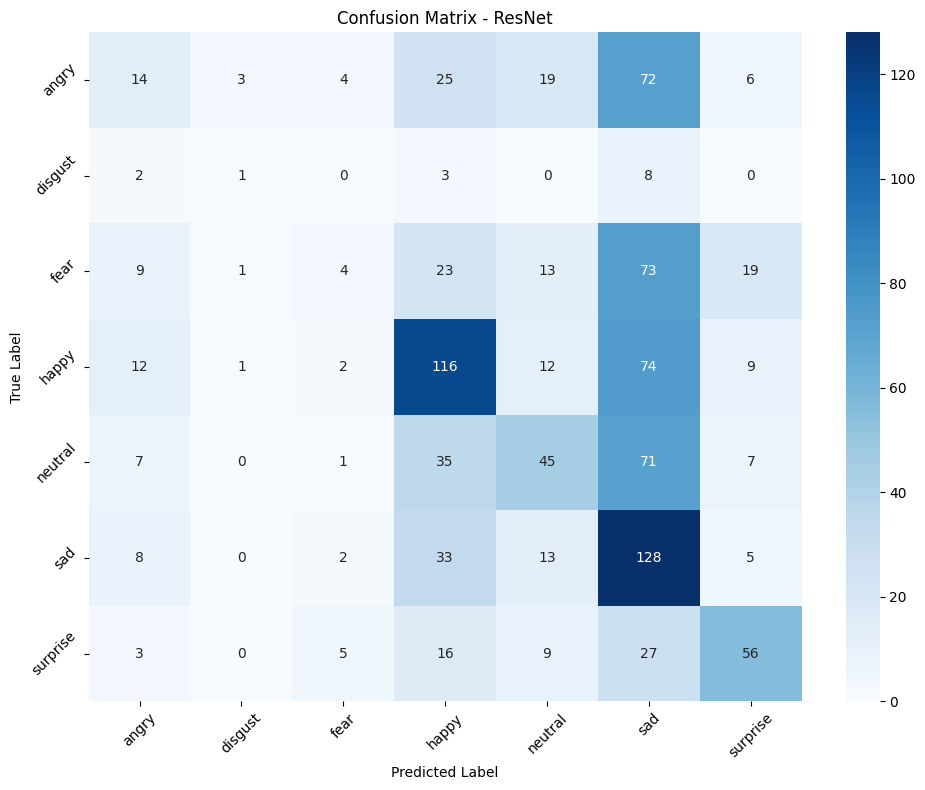

In [17]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Get class names
class_names = train_dataset.classes
print("Classes:", class_names)

# Compute confusion matrix
cm = confusion_matrix(targets, preds)

plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names,
    cmap="Blues"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - ResNet")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()

plt.savefig(f"{PROJECT_PATH}/confusion_matrix_resnet_named.png")
plt.show()

In [15]:
model.eval()
start = time.time()

with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        outputs = model(images)

inference_time = time.time() - start
print("Inference Time:", inference_time)

Inference Time: 9.305041551589966


In [16]:
torch.save(model.state_dict(), f"{PROJECT_PATH}/resnet_model.pth")

import json

results = {
    "training_time": total_training_time,
    "inference_time": inference_time,
    "val_accuracies": val_accuracies,
    "train_losses": train_losses,
    "gpu_memory_MB": torch.cuda.max_memory_allocated()/1024**2
}

with open(f"{PROJECT_PATH}/resnet_results.json", "w") as f:
    json.dump(results, f)

Predicted Emotion: sad
Confidence: 72.63 %


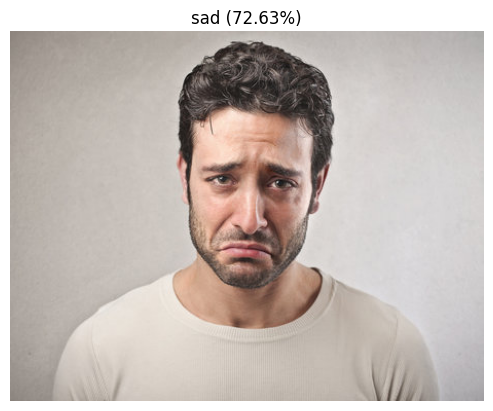

In [24]:
import torch
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Ensure model is in eval mode
model.eval()

# Define same transform used during training
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

image_path = f"{PROJECT_PATH}/sad1.jpg"

# Load image
image = Image.open(image_path).convert("RGB")

# Keep copy for display
display_image = image

# Transform
input_tensor = transform(image).unsqueeze(0).to(device)

# Inference
with torch.no_grad():
    outputs = model(input_tensor)
    probabilities = torch.nn.functional.softmax(outputs[0], dim=0)
    confidence, predicted_class = torch.max(probabilities, 0)

predicted_label = train_dataset.classes[predicted_class.item()]

print("Predicted Emotion:", predicted_label)
print("Confidence:", round(confidence.item()*100, 2), "%")

# Display image with prediction
plt.imshow(display_image)
plt.title(f"{predicted_label} ({confidence.item()*100:.2f}%)")
plt.axis("off")
plt.show()